In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.base_functions.Function import GaussianFunctions


In [3]:
N_points = 50
xl = -2
xr = 2

x = np.linspace(xl, xr, N_points)
xx, yy = np.meshgrid(x, x)
X = np.column_stack([xx.ravel(), yy.ravel()])

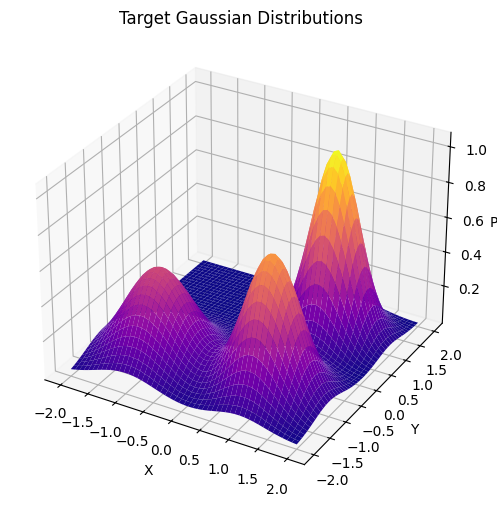

In [4]:
mu1 = torch.tensor([1, 1])
mu2 = torch.tensor([1, -1])
mu3 = torch.tensor([-1, -1])

sigma1 = 0.15 * torch.eye(2)
sigma2 = 0.2 * torch.eye(2)
sigma3 = 0.3 * torch.eye(2)

pdf1 = torch.tensor(multivariate_normal.pdf(X, mu1, sigma1))
pdf2 = torch.tensor(multivariate_normal.pdf(X, mu2, sigma2))
pdf3 = torch.tensor(multivariate_normal.pdf(X, mu3, sigma3))


zz = (pdf1 + pdf2 + pdf3)
zz = zz.reshape(xx.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d', navigate=True)
ax.plot_surface(xx, yy, zz, cmap='plasma')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('PDF')
ax.set_title('Target Gaussian Distributions')

plt.show()

In [5]:
x_values = xx.ravel()
y_values = yy.ravel()
z_values = zz.ravel()

n_samples = 50
n_features = 2
l_functions =  20

In [6]:
total_points = len(x_values)

min_separation = 20

selected_indexes = []

while len(selected_indexes) < n_samples:

    random_index = np.random.randint(total_points)

    if all(abs(random_index - existing_index) >= min_separation for existing_index in selected_indexes):
        selected_indexes.append(random_index)

sampled_indices = selected_indexes

sampled_x = torch.tensor(x_values[sampled_indices], dtype=torch.float32)
sampled_y = torch.tensor(y_values[sampled_indices], dtype=torch.float32)

X = torch.stack((sampled_x, sampled_y), dim=1)
y = z_values[sampled_indices].clone().detach().to(dtype=torch.float32)


In [7]:
gaussian_function = GaussianFunctions(n_features= n_features, n_functions = l_functions)

In [8]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [9]:
model_epochs = 20
ista_epochs = 5000
dictionary_epochs = 2000

ista_alpha = 0.06
ista_lambd = 0.005

dictionary_alpha = 0.01

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)



Training sparse vector: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 4446.09it/s]

Training model:   5%|██████                                                                                                                  | 1/20 [00:04<01:18,  4.13s/it]

Epoch 1 Loss: 0.059916138648986816




Training sparse vector: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:04<00:00, 1226.02it/s]

Training dictionary:  15%|████████████████                                                                                              | 291/2000 [00:00<00:02, 722.34it/s]


Training model:  10%|████████████                                                                                                            | 2/20 [00:10<01:42,  5.70s/it]

Epoch 2 Loss: 0.020806370303034782



...

Training model:  95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████      | 19/20 [02:03<00:06,  6.67s/it]

Epoch 19 Loss: 0.006376530975103378




Training sparse vector: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:04<00:00, 1245.26it/s]

Training dictionary:  19%|████████████████████▋                                                                                         | 376/2000 [00:00<00:02, 746.60it/s]


Training model: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:10<00:00,  6.53s/it]

Epoch 20 Loss: 0.006183570716530085



In [11]:
x_tensor = torch.tensor(x_values)
y_tensor = torch.tensor(y_values)
XY = torch.cat((x_tensor.unsqueeze(1), y_tensor.unsqueeze(1)), dim=1)

Z = model.predict(XY)

/tmp/ipykernel_223729/2142462684.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs_tensor = torch.tensor(sampled_x)
/tmp/ipykernel_223729/2142462684.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ys_tensor = torch.tensor(sampled_y)


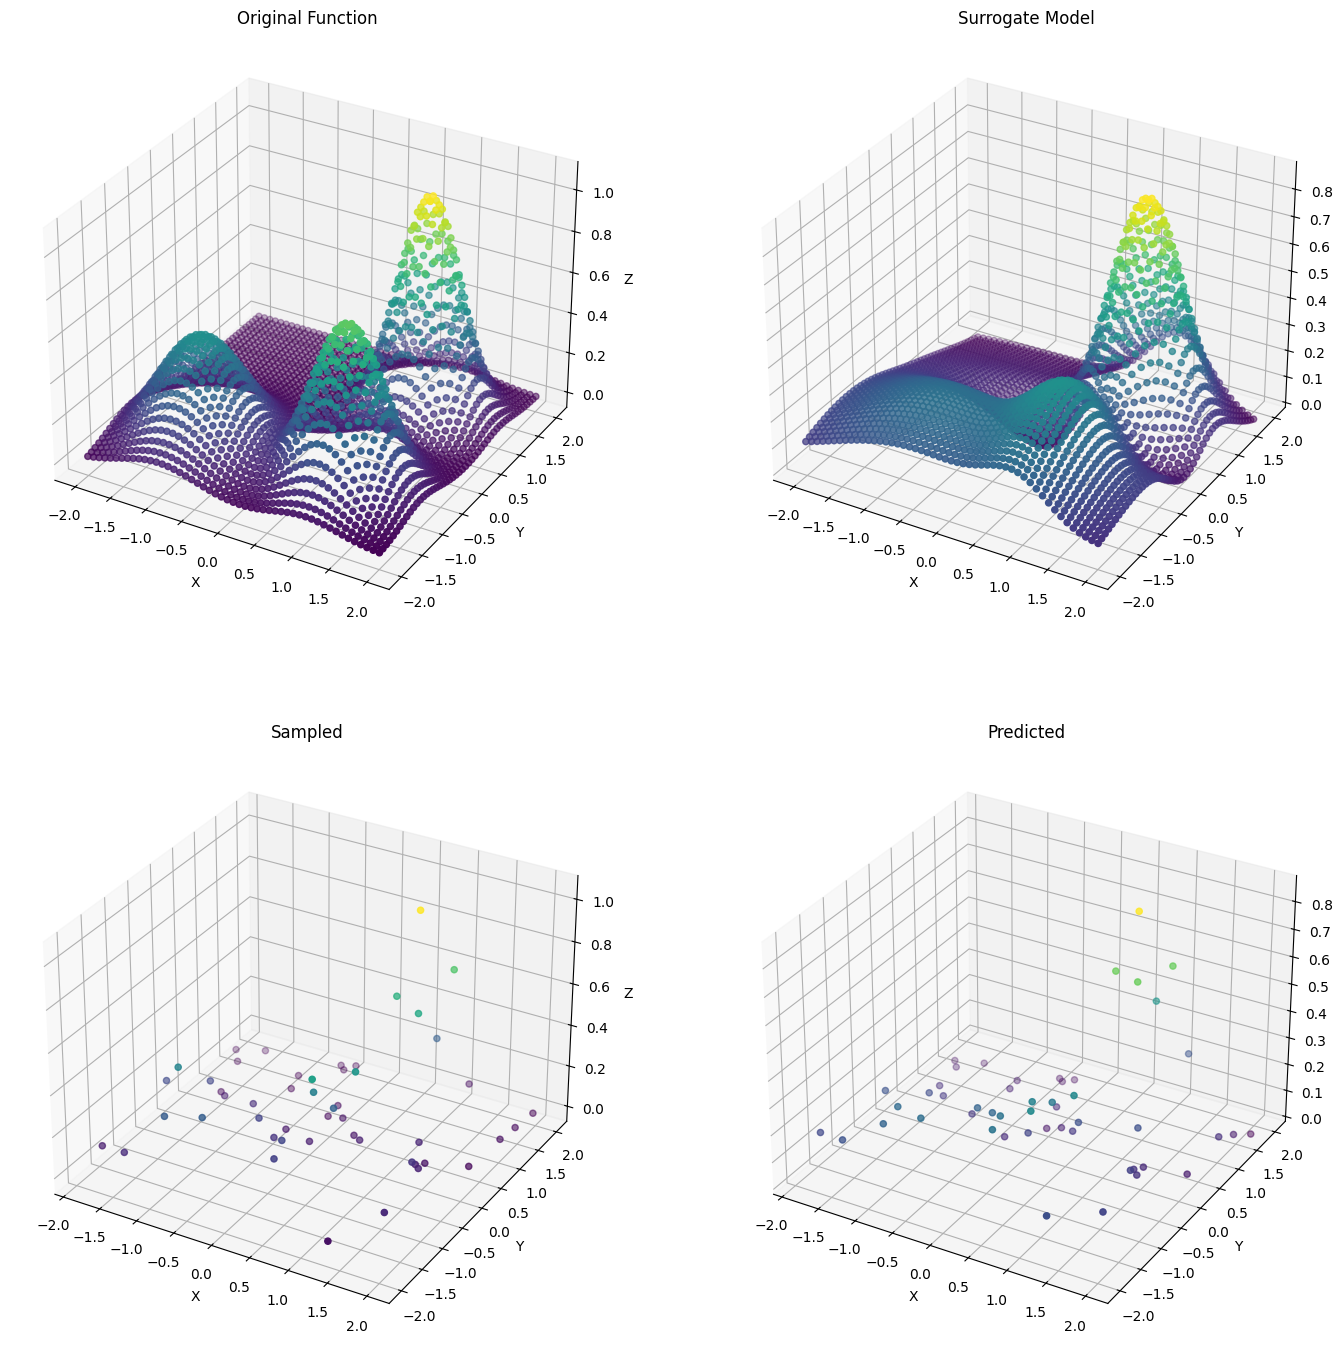

In [23]:
fig = plt.figure(figsize=(17, 17))

ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(x_values, y_values, z_values,c=z_values)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original Function')


ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(x_values, y_values, Z.detach(), c=Z.detach())
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Surrogate Model')
ax2.set_zlim(0)

ax3 = fig.add_subplot(223, projection='3d')
ax3.scatter(sampled_x, sampled_y, y,c=y)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Sampled')

xs_tensor = torch.tensor(sampled_x)
ys_tensor = torch.tensor(sampled_y)
XYs = torch.cat((xs_tensor.unsqueeze(1), ys_tensor.unsqueeze(1)), dim=1)
zp = model.predict(XYs).detach()
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(sampled_x, sampled_y, zp,c=zp)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('Predicted')
ax4.set_zlim(0)



# Show the plot
plt.show()

Training Time: 2.18 minutes


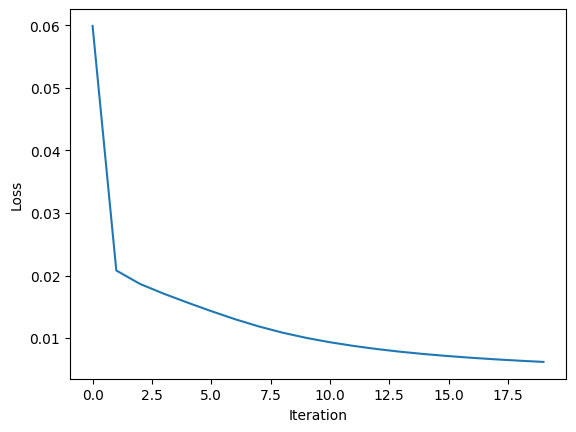

In [24]:
plt.plot(model.losses) 

plt.ylabel('Loss')
plt.xlabel('Iteration')



print(f'Training Time: {model.time / 60:.2f} minutes')
